# Import

In [2]:
# LabOne Q:
from laboneq.simple import *
from laboneq.dsl.quantum import QPU
from laboneq_applications.qpu_types.tunable_transmon import TunableTransmonQubit, TunableTransmonOperations

# User Helper Libraries:
from lib.helpers.setup_helper import *

# from element.qpu_types.test_transmon import TestTransmonQubit, TestTransmonOperations
from qmeas.qsample import QSample
from qmeas.qparameters import QBaseParameters, QLinkedParameters

# Package:
from pprint import pprint
import numpy as np

# Plot:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation

# Workflows:
from laboneq_applications.experiments import (
    resonator_spectroscopy,
    resonator_spectroscopy_amplitude,
    qubit_spectroscopy,
    amplitude_rabi,
    ramsey,
    drag_q_scaling,
    lifetime_measurement,
    echo,
)

ModuleNotFoundError: No module named 'laboneq_applications'

# Settings System

In [ ]:
cooldown_nr = 1
# Define device setup
descriptor_file = "./descriptor.yml"

In [3]:
#dictionary for sample parameters
sample_parameters = {
    # 'folder_name': r'N:\xld\Kubatkin\Data',
    'folder_name': r'.\Data'
    'sample_name': r'S3',
    'structure_name': 'Q2'
}

qsample_params = QSample(directory=sample_parameters['folder_name'], 
                         sample=sample_parameters['sample_name'], 
                         structure=sample_parameters['structure_name'])

In [4]:
# a collection of qubit control and readout parameters as a python dictionary
qubit_parameters = {
    'ro_freq'       : 136e6,        # readout frequency of qubit 0 in [Hz] - relative to local oscillator for readout drive upconversion
    'ro_amp'        : 0.5,          # readout amplitude
    'ro_amp_spec'   : 0.05,         # readout amplitude for spectroscopy 0.05
    'ro_len'        : 2.0e-6,       # readout pulse length in [s]
    'ro_len_spec'   : 4.0e-6,       # readout pulse length for resonator spectroscopy in [s]
    'ro_delay'      : 0.0,          # readout delay after last drive signal in [s]
    'ro_int_delay'  : 330e-9,       # readout line offset calibration - delay between readout pulse and start of signal acquisition in [s]
    
    'th_res_freq'   : 0.0,
    
    'qb_freq'       : 50e6,         # qubit 0 drive frequency in [Hz] - relative to local oscillator for qubit drive upconversion
    'qb_anharm'     : 200e6,
    'qb_amp_spec'   : 0.0001,       # drive amplitude of qubit spectroscopy
    'qb_len_spec'   : 15e-6,        # drive pulse length for qubit spectroscopy in [s]
    'qb_len'        : 6e-8,         # qubit drive pulse length in [s]
    'pi_amp'        : 1.0,          # qubit drive amplitude for pi pulse
    'pi_half_amp'   : 0.25,         # qubit drive amplitude for pi/2 pulse
    'qb_t1'         : 6e-6,         # qubit T1 time
    'qb_t2_ramsey'  : 1e-6,         # qubit T2 time
    'ramsey_det'    : 2e6,          # qubit frequency detuning relative to qb_freq in [Hz]
    'qb_t2_echo'    : 1e-6,         # qubit T2 time
    'relax'         : 500e-6        # delay time after each measurement for qubit reset in [s]
}

qubit_parameters = QBaseParameters(sample=qsample_params,
                                    name=f'qubit_parameters_cooldown_{cooldown_nr}',
                                    parameters=qubit_parameters)

In [5]:
# up / downconversion settings - to convert between IF and RF frequencies 
# steps of 200Mh
lo_settings = {
    'qb_lo'         : 3.8e9,        # qubit LO frequency in [Hz]
    'ro_lo'         : 6.2e9         # R1 readout LO frequency in [Hz]
}

lo_settings = QBaseParameters(sample=qsample_params,
                             name=f'lo_settings_cooldown_{cooldown_nr}',
                             parameters=lo_settings)

In [6]:
device_setup = DeviceSetup.from_yaml(
    filepath=descriptor_file,
    server_host="111.22.33.44",
    server_port="8004",
    setup_name="setup",
)

In [7]:
# define Calibration object based on qubit control and readout parameters
calibration = define_calibration(parameters=qubit_parameters, lo_settings=lo_settings)

# apply calibration to device setup
device_setup.set_calibration(calibration)

In [8]:
## define shortcut to logical signals for convenience
lsg_q0                  = device_setup.logical_signal_groups["q0"].logical_signals

drive_Oscillator_q0     = lsg_q0["drive_line"].oscillator
drive_ef_Oscillator_q0  = lsg_q0["drive_ef_line"].oscillator
readout_Oscillator_q0   = lsg_q0["measure_line"].oscillator
acquire_Oscillator_q0   = lsg_q0["acquire_line"].oscillator

lsg_q0["acquire_line"].port_delay
lsg_q0["acquire_line"].range = -35

In [9]:
device_setup.logical_signal_groups

{'q0': LogicalSignalGroup(
│   uid='q0',
│   logical_signals={
│   │   'drive_line': LogicalSignal(
│   │   │   uid='q0/drive_line',
│   │   │   direction=IODirection.OUT,
│   │   │   name='drive_line',
│   │   │   calibration=SignalCalibration(
│   │   │   │   amplitude=None,
│   │   │   │   delay_signal=None,
│   │   │   │   local_oscillator=Oscillator(
│   │   │   │   │   uid='osc_1',
│   │   │   │   │   frequency=3800000000.0,
│   │   │   │   │   modulation_type=ModulationType.AUTO,
│   │   │   │   │   carrier_type=None
│   │   │   │   ),
│   │   │   │   voltage_offset=None,
│   │   │   │   mixer_calibration=None,
│   │   │   │   precompensation=None,
│   │   │   │   oscillator=Oscillator(
│   │   │   │   │   uid='q0_drive_osc',
│   │   │   │   │   frequency=50000000.0,
│   │   │   │   │   modulation_type=ModulationType.HARDWARE,
│   │   │   │   │   carrier_type=None
│   │   │   │   ),
│   │   │   │   port_delay=None,
│   │   │   │   port_mode=None,
│   │   │   │   range=5,
│   │  

In [10]:
qubits = TestTransmonQubit.from_device_setup(device_setup)

for q in qubits:
    print("-------------")
    print("Qubit UID:", q.uid)
    print("Qubit logical signals:")
    for sig, lsg in q.signals.items():
        print(f"  {sig:<10} ('{lsg:>10}')")

-------------
Qubit UID: q0
Qubit logical signals:
  drive      ('q0/drive_line')
  drive_ef   ('q0/drive_ef_line')
  th_res     ('q0/th_res_line')
  measure    ('q0/measure_line')
  acquire    ('q0/acquire_line')


In [ ]:
for q in qubits:
    q.parameters.ge_drive_pulse["sigma"] = 0.25
    q.parameters.readout_amplitude = 0.5
    q.parameters.reset_delay_length = 10e-6
    q.parameters.readout_range_out = -25
    q.parameters.readout_lo_frequency = 5e9
    q.parameters.drive_range = 5
    q.parameters.readout_range_in = -45
    q.parameters.readout_integration_delay = 80

qubits[0].parameters.drive_lo_frequency = 3.6e9
qubits[0].parameters.resonance_frequency_ge = 3.748e9
qubits[0].parameters.resonance_frequency_ef = 3.51e9
qubits[0].parameters.readout_resonator_frequency = 5.037e9

qubits[1].parameters.drive_lo_frequency = 6.4e9
qubits[1].parameters.resonance_frequency_ge = 6.5e9
qubits[1].parameters.resonance_frequency_ef = 6.3e9
qubits[1].parameters.readout_resonator_frequency = 7.3e9

In [12]:
qops = TestTransmonOperations()
qpu = QPU(qubits, quantum_operations=qops)
qpu.quantum_elements

[TestTransmonQubit(
│   uid='q0',
│   signals={
│   │   'drive': 'q0/drive_line',
│   │   'drive_ef': 'q0/drive_ef_line',
│   │   'th_res': 'q0/th_res_line',
│   │   'measure': 'q0/measure_line',
│   │   'acquire': 'q0/acquire_line'
│   },
│   parameters=TestTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=0,
│   │   ge_T2=0,
│   │   ge_T2_star=0,
│   │   ef_T1=0,
│   │   ef_T2=0,
│   │   ef_T2_star=0,
│   │   drive_lo_frequency=3800000000.0,
│   │   readout_lo_frequency=6200000000.0,
│   │   resonance_frequency_ge=6300000000.0,
│   │   resonance_frequency_ef=6000000000.0,
│   │   readout_resonator_frequency=6200000000.0,
│   │   ge_drive_amplitude_pi=0.2,
│   │   ge_drive_amplitude_pi2=0.1,
│   │   ge_drive_length=5e-08,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │   'sigma': 0.25
│   │   },
│   │   ef_drive_amplitude_pi=0.2,
│   │   ef_drive_amplitude_pi2=0.1,
│   │   ef_drive_length=5e-08,
│   │   ef_drive_pulse={
│   │   │   'fu

In [13]:
qops.measure

Operation(op=<MultiMethod
('object', 'TestTransmonQubit', 'object', 'object', 'object'): TestTransmonOperations.measure
>, op_name=measure, neartime=False, supports_broadcast=True)

In [14]:
session = Session(device_setup)
session.connect(do_emulation=True)  # do_emulation=False when at a real setup

[2026.07.14 14:22:35.912] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/superconducting-qubit-thermometry/laboneq_output/log
[2026.07.14 14:22:35.914] INFO    VERSION: laboneq 26.4.0
[2026.07.14 14:22:35.915] INFO    Connecting to data server at 111.22.33.44:8004
[2026.07.14 14:22:35.915] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at 111.22.33.44:8004
[2026.07.14 14:22:35.917] INFO    Configuring the device setup
[2026.07.14 14:22:35.918] INFO    The device setup is configured


# Exp1. Resonator Spectroscopy

[2026.07.14 14:22:36.265] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.14 14:22:36.266] INFO      Workflow 'resonator_spectroscopy': execution started at 2026-07-14            
[2026.07.14 14:22:36.266] INFO      11:22:36.262841Z                                                              
[2026.07.14 14:22:36.266] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.14 14:22:36.267] INFO    Task 'temporary_qpu': started at 2026-07-14 11:22:36.267022Z
[2026.07.14 14:22:36.267] INFO    Task 'temporary_qpu': ended at 2026-07-14 11:22:36.267629Z
[2026.07.14 14:22:36.268] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-07-14 
[2026.07.14 14:22:36.268] INFO    11:22:36.268025Z
[2026.07.14 14:22:36.268] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-07-14 11:22:36.268618Z
[2026.07.14 14:22:36.268] INFO    Task 'create_experiment': started at 2026-07-14 11:

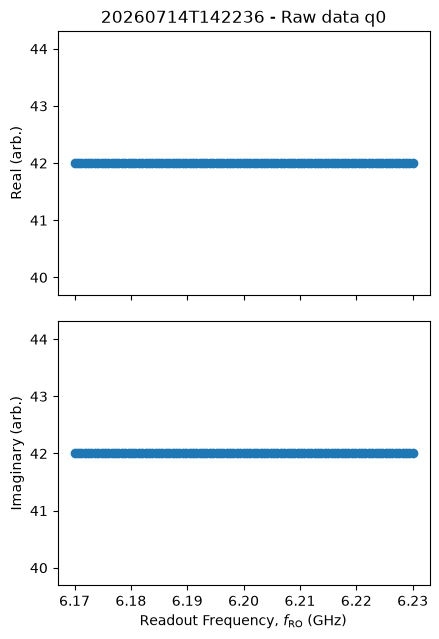

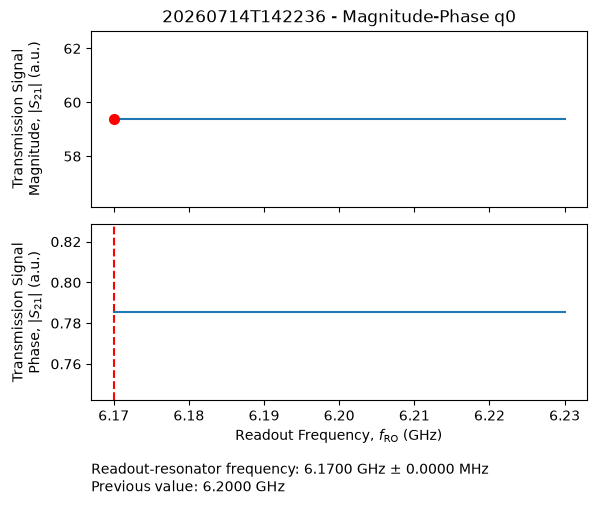

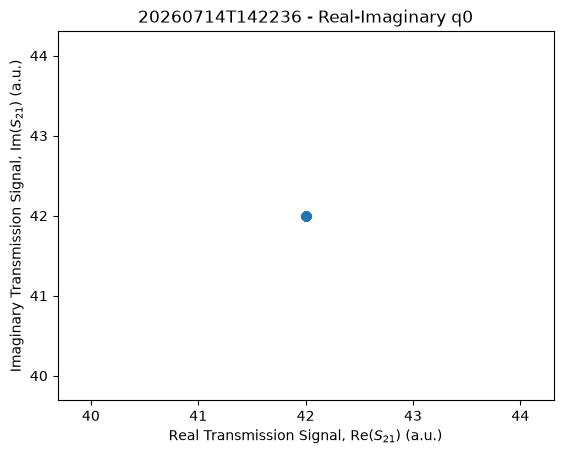

In [15]:
options = resonator_spectroscopy.experiment_workflow.options()
options.update(True) # updates the qubit parameter "readout_resonator_frequency"
options.close_figures(False) # plot figure

# The resonator spectroscopy can only be done on one qubit at a time
qubit_to_measure = qubits[0]

frequencies = qubit_to_measure.parameters.readout_resonator_frequency + np.linspace(
    -30e6, 30e6, 101
)

exp_workflow = resonator_spectroscopy.experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    frequencies=frequencies,
    options=options,
)
workflow_result = exp_workflow.run()

Readout resonator frequency:  6170000000.0
{'new_parameter_values': {'q0': {'readout_resonator_frequency': 6170000000.0+/-0}},
 'old_parameter_values': {'q0': {'readout_resonator_frequency': 6200000000.0}}}


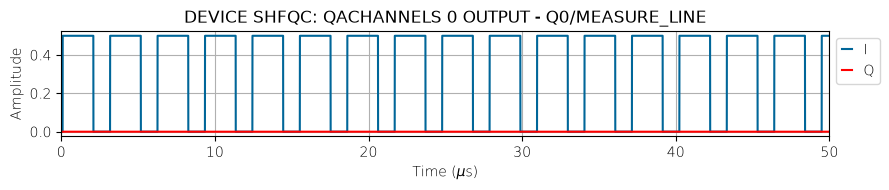

In [16]:
# Print
print("Readout resonator frequency: ", qubit_to_measure.parameters.readout_resonator_frequency)
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
pprint(analysis_workflow_result.output)

# Plot
compiled_experiment = workflow_result.tasks["compile_experiment"].output
plot_simulation(compiled_experiment, length=50e-6, signal_names_to_show=["measure"])

# Exp2. Qubit Spectroscopy

In [17]:
options = qubit_spectroscopy.experiment_workflow.options()
options.count(4096)
options.update(True)  # updates the qubit parameter "resonance_frequency_ge"
options.close_figures(False) # plot figure

qubits_to_measure = qubits

temporary_parameters = {}
for q in qubits_to_measure:
    temp_pars = deepcopy(q.parameters)
    temp_pars.drive_range = -30
    temp_pars.spectroscopy_amplitude = 1
    temporary_parameters[q.uid] = temp_pars

frequencies = [
    q.parameters.resonance_frequency_ge + np.linspace(-20e6, 20e6, 201)
    for q in qubits_to_measure
]
exp_workflow = qubit_spectroscopy.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    temporary_parameters=temporary_parameters,
    frequencies=frequencies,
    options=options,
)
workflow_result = exp_workflow.run()

[2026.07.14 14:22:40.453] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.14 14:22:40.453] INFO      Workflow 'qubit_spectroscopy': execution started at 2026-07-14                
[2026.07.14 14:22:40.454] INFO      11:22:40.453008Z                                                              
[2026.07.14 14:22:40.454] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.14 14:22:40.455] INFO    Task 'temporary_qpu': started at 2026-07-14 11:22:40.454835Z
[2026.07.14 14:22:40.455] INFO    Task 'temporary_qpu': ended at 2026-07-14 11:22:40.455532Z
[2026.07.14 14:22:40.456] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-07-14 
[2026.07.14 14:22:40.457] INFO    11:22:40.455946Z
[2026.07.14 14:22:40.457] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-07-14 11:22:40.457396Z
[2026.07.14 14:22:40.457] INFO    Task 'create_experiment': started at 2026-07-14 11:

[2026.07.14 14:22:40.458] ERROR   Task 'create_experiment': failed at 2026-07-14 11:22:40.458805Z with: 


[2026.07.14 14:22:40.459] ERROR   DispatchError('measure_section_length: 0 methods found', (<class 'object'>, 


[2026.07.14 14:22:40.459] ERROR   DispatchError('measure_section_length: 0 methods found', (<class 'object'>, 


[2026.07.14 14:22:40.459] ERROR   <class 'element.qpu_types.test_transmon.qubit_types.TestTransmonQubit'>), set())


[2026.07.14 14:22:40.459] ERROR   <class 'element.qpu_types.test_transmon.qubit_types.TestTransmonQubit'>), set())


[2026.07.14 14:22:40.460] INFO    Task 'create_experiment': ended at 2026-07-14 11:22:40.459958Z
[2026.07.14 14:22:40.460] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.14 14:22:40.460] INFO      Workflow 'qubit_spectroscopy': execution ended at 2026-07-14                  
[2026.07.14 14:22:40.460] INFO      11:22:40.460404Z                                                              
[2026.07.14 14:22:40.461] INFO     ────────────────────────────────────────────────────────────────────────────── 


DispatchError: ('measure_section_length: 0 methods found', (<class 'object'>, <class 'element.qpu_types.test_transmon.qubit_types.TestTransmonQubit'>), set())

In [ ]:
# Print
print("Resonance frequency ge: ", qubit_to_measure[0].parameters.resonance_frequency_ge)
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
pprint(analysis_workflow_result.output)

# Plot
compiled_experiment = workflow_result.tasks["compile_experiment"].output
plot_simulation(compiled_experiment, length=50e-6, signal_names_to_show=["measure"])

In [ ]:
[q.parameters.resonance_frequency_ge for q in qubits]

# Exp3. Amplitude Rabi

In [ ]:
options = amplitude_rabi.experiment_workflow.options()
# updates the qubit parameters "ge_drive_amplitude_pi" and ge_drive_amplitude_pi2
options.update(False)
options.close_figures(False) # Plot figures

transition_to_calibrate = "ge"
options.transition(transition_to_calibrate)
options.cal_states(transition_to_calibrate)

qubits_to_measure = qubits

exp_workflow = amplitude_rabi.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    amplitudes=[np.linspace(0, 1, 21) for q in qubits_to_measure],
    options=options,
)
workflow_result = exp_workflow.run()

In [ ]:
# Print
print("Drive amplitude pi ge: ", qubit_to_measure[0].parameters.ge_drive_amplitude_pi)
print("Drive amplitude pi2 ge", qubit_to_measure[0].parameters.ge_drive_amplitude_pi2)
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
pprint(analysis_workflow_result.output)

# Plot
compiled_experiment = workflow_result.tasks["compile_experiment"].output
plot_simulation(compiled_experiment, length=50e-6, signal_names_to_show=["measure"])

In [ ]:
[
    (q.parameters.ge_drive_amplitude_pi, q.parameters.ge_drive_amplitude_pi2)
    for q in qubits
]

# Exp4. Ramsey

In [ ]:
options = ramsey.experiment_workflow.options()
# updates the qubit parameters "resonance_frequency_ge" and ge_T2_star
options.update(True)
options.close_figures(False) # Plot figures

transition_to_calibrate = "ge"
options.transition(transition_to_calibrate)
options.cal_states(transition_to_calibrate)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Ramsey in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
qubits_to_measure = [qubits[0], qubits[2]]

delays = [
    np.linspace(0, 1e-6, 51)
    if transition_to_calibrate == "ef"
    else np.linspace(0, 20e-6, 51)
    for q in qubits_to_measure
]
detunings = [
    11.76e6 if transition_to_calibrate == "ef" else 0.673e6 for q in qubits_to_measure
]

exp_workflow = ramsey.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    detunings=detunings,
    options=options,
)

workflow_result = exp_workflow.run()

In [ ]:
# Print
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
pprint(analysis_workflow_result.output)

# Plot
compiled_experiment = workflow_result.tasks["compile_experiment"].output
plot_simulation(compiled_experiment, length=50e-6, signal_names_to_show=["measure"])

In [ ]:
[q.parameters.resonance_frequency_ge * 1e6 for q in qubits]

In [ ]:
[q.parameters.ge_T2_star * 1e6 for q in qubits]

# Exp5. DRAG Calib

In [ ]:
options = drag_q_scaling.experiment_workflow.options()
options.update(True)  # updates the qubit parameter 'ge_drive_pulse["beta"]'
options.close_figures(False) # Plot figures

transition_to_calibrate = "ge"
options.transition(transition_to_calibrate)
options.cal_states(transition_to_calibrate)

qubits_to_measure = qubits

exp_workflow = drag_q_scaling.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    q_scalings=[np.linspace(-0.03, 0.03, 11) for _ in qubits_to_measure],
    options=options,
)
workflow_result = exp_workflow.run()

In [ ]:
# Print
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
pprint(analysis_workflow_result.output)

# Plot
compiled_experiment = workflow_result.tasks["compile_experiment"].output
plot_simulation(compiled_experiment, length=50e-6, signal_names_to_show=["measure"])

In [ ]:
[q.parameters.ge_drive_pulse["beta"] for q in qubits]

# Exp6. T1

In [ ]:
options = lifetime_measurement.experiment_workflow.options()
options.update(True)  # updates the qubit parameter "ge_T1"
options.close_figures(False) # Plot figures

qubits_to_measure = qubits

exp_workflow = lifetime_measurement.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    temporary_parameters=temporary_parameters,
    delays=[np.linspace(0, 100e-6, 50) for q in qubits_to_measure],
    options=options,
)
workflow_result = exp_workflow.run()

In [ ]:
# Print
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
pprint(analysis_workflow_result.output)

# Plot
compiled_experiment = workflow_result.tasks["compile_experiment"].output
plot_simulation(compiled_experiment, length=50e-6, signal_names_to_show=["measure"])

In [ ]:
[q.parameters.ge_T1 * 1e6 for q in qubits]

# Exp7. Echo

In [ ]:
options = echo.experiment_workflow.options()
options.update(True)  # updates the qubit parameter "ge_T2"

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Echo in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
qubits_to_measure = [qubits[0], qubits[2]]

exp_workflow = echo.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=[np.linspace(0, 100e-6, 50) for q in qubits_to_measure],
    options=options,
)
workflow_result = exp_workflow.run()

In [ ]:
# Print
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
pprint(analysis_workflow_result.output)

# Plot
compiled_experiment = workflow_result.tasks["compile_experiment"].output
plot_simulation(compiled_experiment, length=50e-6, signal_names_to_show=["measure"])

In [ ]:
[q.parameters.ge_T2 * 1e6 for q in qubits]